# Order Placement Prediction Project

This notebook builds an end-to-end classification pipeline for predicting `order_placed` from the provided Kaggle-style train/test split.

Workflow:
- inspect the dataset and quantify class imbalance
- engineer features from timestamps and missingness patterns
- compare multiple models with stratified validation
- tune the decision threshold on the validation set
- retrain the best pipeline on the full training set and export predictions

In [11]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", context="notebook")

In [12]:
train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")

print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")

Train shape: (297236, 18)
Test shape:  (99639, 17)


In [13]:
display(train.head())
display(train.info())
display(train.isna().sum().sort_values(ascending=False))

,id,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16,f17,order_placed
0,0,082f3074-39b5-448d-b696-1e99de783de7,2017-03-07T00:17:41.049Z,2017-03-07T00:47:41.049Z,2017-03-07T00:40:04.857Z,420,PAGE_LOAD,0,NC,0,0.0,F,10.0,50.0,1.0,1048576.0,IGNORED,0
1,2,70b9ed34-4de3-47c4-ae00-2a0f4cd4579f,2017-03-03T07:17:25.925Z,2017-03-03T07:47:25.925Z,2017-03-03T07:42:06.853Z,480,PAGE_LOAD,0,NC,0,0.0,P,75.0,950.0,1.0,1048576.0,IGNORED,0
2,3,5838186d-164f-4f51-bd35-c82a293d5e14,2017-03-06T14:31:23.833Z,2017-03-06T15:01:23.833Z,2017-03-06T14:51:43.569Z,480,PAGE_LOAD,0,NC,0,0.0,P,10.0,50.0,1.0,1048576.0,IGNORED,0
3,4,ee595e60-f3b3-44e7-bf78-25c834931ab9,2017-03-03T15:45:27.598Z,2017-03-03T16:15:27.598Z,2017-03-03T15:49:30.165Z,480,PAGE_LOAD,0,NC,0,0.0,F,10.0,50.0,1.0,1048576.0,IGNORED,0
4,5,128bfbf6-e949-42d5-8e23-48d1d9f83bf2,2017-03-05T10:39:37.622Z,2017-03-05T11:09:37.622Z,2017-03-05T11:07:28.130Z,480,PAGE_LOAD,0,NC,0,0.0,P,10.0,50.0,1.0,1048576.0,IGNORED,0


<class 'pandas.DataFrame'>
RangeIndex: 297236 entries, 0 to 297235
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            297236 non-null  int64  
 1   f2            297236 non-null  str    
 2   f3            297236 non-null  str    
 3   f4            297236 non-null  str    
 4   f5            297236 non-null  str    
 5   f6            297236 non-null  int64  
 6   f7            297236 non-null  str    
 7   f8            297236 non-null  int64  
 8   f9            297236 non-null  str    
 9   f10           297236 non-null  int64  
 10  f11           297236 non-null  float64
 11  f12           206718 non-null  str    
 12  f13           206718 non-null  float64
 13  f14           206718 non-null  float64
 14  f15           206718 non-null  float64
 15  f16           297236 non-null  float64
 16  f17           206718 non-null  str    
 17  order_placed  297236 non-null  int64  
dtypes: float64(5), 

None

f14             90518
f15             90518
f12             90518
f17             90518
f13             90518
id                  0
f2                  0
f3                  0
f5                  0
f4                  0
f10                 0
f9                  0
f8                  0
f7                  0
f6                  0
f11                 0
f16                 0
order_placed        0
dtype: int64

,count,percentage
order_placed,,
0,288592,97.09
1,8644,2.91


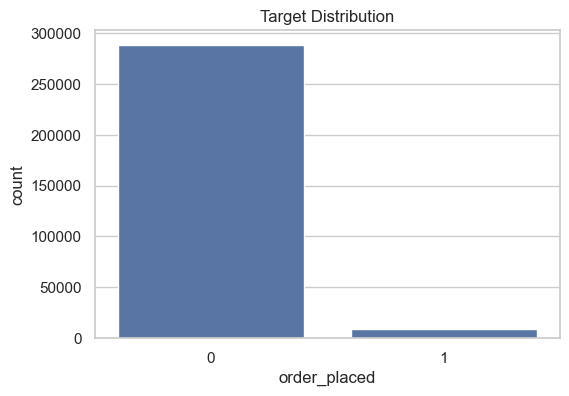

In [14]:
target_counts = train["order_placed"].value_counts().sort_index()
target_ratio = train["order_placed"].value_counts(normalize=True).sort_index().mul(100).round(2)

display(pd.DataFrame({"count": target_counts, "percentage": target_ratio}))

plt.figure(figsize=(6, 4))
sns.countplot(data=train, x="order_placed")
plt.title("Target Distribution")
plt.show()

## Feature engineering

The raw data contains timestamps, categorical event descriptors, and several columns with systematic missing values. The feature builder below:
- converts the three timestamp columns to datetime
- derives session timing features such as hour, weekday, weekend, and elapsed times
- adds missing-value indicators for the sparse columns
- removes obvious identifiers and raw timestamps after extracting useful information

In [15]:
TIME_COLUMNS = ["f3", "f4", "f5"]
SPARSE_COLUMNS = ["f12", "f13", "f14", "f15", "f17"]


def build_features(df: pd.DataFrame) -> pd.DataFrame:
    data = df.copy()

    for col in TIME_COLUMNS:
        data[col] = pd.to_datetime(data[col], utc=True, errors="coerce")

    data["session_length_sec"] = (data["f4"] - data["f3"]).dt.total_seconds()
    data["action_delay_sec"] = (data["f5"] - data["f3"]).dt.total_seconds()
    data["time_left_after_action_sec"] = (data["f4"] - data["f5"]).dt.total_seconds()

    data["start_hour"] = data["f3"].dt.hour
    data["start_dayofweek"] = data["f3"].dt.dayofweek
    data["start_is_weekend"] = data["start_dayofweek"].isin([5, 6]).astype(int)
    data["action_hour"] = data["f5"].dt.hour

    for col in SPARSE_COLUMNS:
        data[f"{col}_missing"] = data[col].isna().astype(int)

    data["f2_prefix"] = data["f2"].astype(str).str[:2]

    data = data.drop(columns=["id", "f2", "f3", "f4", "f5"], errors="ignore")
    return data


X = build_features(train.drop(columns=["order_placed"]))
y = train["order_placed"].copy()
X_test = build_features(test)

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Modeling rows: {X.shape[0]}")
print(f"Modeling features: {X.shape[1]}")
print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")
display(X.head())

Modeling rows: 297236
Modeling features: 25
Numeric features: 20
Categorical features: 5


,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16,f17,session_length_sec,action_delay_sec,time_left_after_action_sec,start_hour,start_dayofweek,start_is_weekend,action_hour,f12_missing,f13_missing,f14_missing,f15_missing,f17_missing,f2_prefix
0,420,PAGE_LOAD,0,NC,0,0.0,F,10.0,50.0,1.0,1048576.0,IGNORED,1800.0,1343.808,456.192,0,1,0,0,0,0,0,0,0,08
1,480,PAGE_LOAD,0,NC,0,0.0,P,75.0,950.0,1.0,1048576.0,IGNORED,1800.0,1480.928,319.072,7,4,0,7,0,0,0,0,0,70
2,480,PAGE_LOAD,0,NC,0,0.0,P,10.0,50.0,1.0,1048576.0,IGNORED,1800.0,1219.736,580.264,14,0,0,14,0,0,0,0,0,58
3,480,PAGE_LOAD,0,NC,0,0.0,F,10.0,50.0,1.0,1048576.0,IGNORED,1800.0,242.567,1557.433,15,4,0,15,0,0,0,0,0,ee
4,480,PAGE_LOAD,0,NC,0,0.0,P,10.0,50.0,1.0,1048576.0,IGNORED,1800.0,1670.508,129.492,10,6,1,11,0,0,0,0,0,12


In [16]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("Training split:", X_train.shape, y_train.mean().round(4))
print("Validation split:", X_valid.shape, y_valid.mean().round(4))

Training split: (237788, 25) 0.0291
Validation split: (59448, 25) 0.0291


## Modeling strategy

Because the positive class is rare, overall accuracy is not enough. We compare models using:
- PR-AUC (`average_precision`) as the main selection metric
- ROC-AUC for ranking quality
- F1, precision, and recall after thresholding at 0.5

In [17]:
linear_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            numeric_features,
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore")),
            ]),
            categorical_features,
        ),
    ]
)

hgb_preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numeric_features),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                (
                    "encoder",
                    OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
                ),
            ]),
            categorical_features,
        ),
    ]
)

models = {
    "dummy": Pipeline([
        ("prep", linear_preprocessor),
        ("model", DummyClassifier(strategy="prior")),
    ]),
    "logistic": Pipeline([
        ("prep", linear_preprocessor),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced")),
    ]),
    "random_forest": Pipeline([
        ("prep", linear_preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                min_samples_leaf=2,
                random_state=42,
                n_jobs=-1,
                class_weight="balanced_subsample",
            ),
        ),
    ]),
    "hist_gradient_boosting": Pipeline([
        ("prep", hgb_preprocessor),
        (
            "model",
            HistGradientBoostingClassifier(
                random_state=42,
                learning_rate=0.05,
                max_depth=8,
                max_iter=250,
                min_samples_leaf=40,
            ),
        ),
    ]),
}


def evaluate_model(name: str, pipeline: Pipeline) -> dict:
    fitted = clone(pipeline)
    fitted.fit(X_train, y_train)
    valid_proba = fitted.predict_proba(X_valid)[:, 1]
    valid_pred = (valid_proba >= 0.5).astype(int)

    return {
        "model": name,
        "average_precision": average_precision_score(y_valid, valid_proba),
        "roc_auc": roc_auc_score(y_valid, valid_proba),
        "f1_at_0.5": f1_score(y_valid, valid_pred),
        "precision_at_0.5": precision_score(y_valid, valid_pred, zero_division=0),
        "recall_at_0.5": recall_score(y_valid, valid_pred, zero_division=0),
        "pipeline": fitted,
        "valid_proba": valid_proba,
    }


results = [evaluate_model(name, pipeline) for name, pipeline in models.items()]
results_df = (
    pd.DataFrame(results)
    .drop(columns=["pipeline", "valid_proba"])
    .sort_values(by="average_precision", ascending=False)
    .reset_index(drop=True)
)
display(results_df)

,model,average_precision,roc_auc,f1_at_0.5,precision_at_0.5,recall_at_0.5
0,hist_gradient_boosting,0.463200,0.969466,0.279714,0.614931,0.181029
1,random_forest,0.407553,0.965259,0.418046,0.276675,0.854829
2,logistic,0.215482,0.902336,0.234263,0.137108,0.803933
3,dummy,0.029084,0.500000,0.000000,0.000000,0.000000


In [18]:
best_result = max(results, key=lambda item: item["average_precision"])
best_name = best_result["model"]
best_pipeline = best_result["pipeline"]
valid_proba = best_result["valid_proba"]

print(f"Best model by validation PR-AUC: {best_name}")

precision, recall, thresholds = precision_recall_curve(y_valid, valid_proba)
threshold_candidates = np.append(thresholds, 1.0)
f1_scores = 2 * precision * recall / np.clip(precision + recall, 1e-12, None)
best_threshold_idx = int(np.nanargmax(f1_scores))
best_threshold = threshold_candidates[min(best_threshold_idx, len(threshold_candidates) - 1)]

print(f"Best threshold by validation F1: {best_threshold:.4f}")
print(f"Validation F1 at tuned threshold: {np.nanmax(f1_scores):.4f}")

Best model by validation PR-AUC: hist_gradient_boosting
Best threshold by validation F1: 0.2352
Validation F1 at tuned threshold: 0.4872


              precision    recall  f1-score   support

           0     0.9886    0.9716    0.9801     57719
           1     0.3984    0.6270    0.4872      1729

    accuracy                         0.9616     59448
   macro avg     0.6935    0.7993    0.7336     59448
weighted avg     0.9715    0.9616    0.9657     59448



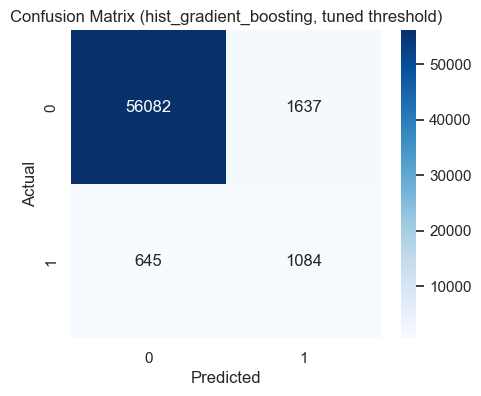

In [19]:
valid_pred_tuned = (valid_proba >= best_threshold).astype(int)

print(classification_report(y_valid, valid_pred_tuned, digits=4))

cm = confusion_matrix(y_valid, valid_pred_tuned)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix ({best_name}, tuned threshold)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Retrain on full training data and export predictions

Two files are exported:
- `submission_labels.csv`: binary class predictions using the tuned threshold
- `submission_probabilities.csv`: predicted positive-class probabilities

If the course rubric or Kaggle page provides a sample submission, adapt the exported columns to match that format exactly.

In [20]:
final_pipeline = clone(models[best_name])
final_pipeline.fit(X, y)

test_proba = final_pipeline.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= best_threshold).astype(int)

submission_labels = pd.DataFrame({
    "id": test["id"],
    "order_placed": test_pred,
})

submission_probabilities = pd.DataFrame({
    "id": test["id"],
    "order_placed_probability": test_proba,
})

submission_labels.to_csv("submission_labels.csv", index=False)
submission_probabilities.to_csv("submission_probabilities.csv", index=False)

display(submission_labels.head())
display(submission_probabilities.head())

,id,order_placed
0,1,0
1,8,0
2,10,0
3,15,0
4,20,0


,id,order_placed_probability
0,1,0.000055
1,8,0.005277
2,10,0.000062
3,15,0.000079
4,20,0.000106


## Report notes

Useful points to include in the written report or presentation:
- The dataset is strongly imbalanced, so PR-AUC and recall-sensitive metrics matter more than accuracy alone.
- Timestamp-derived features are likely informative because user behavior often depends on session timing and time-to-action.
- Missingness in `f12`, `f13`, `f14`, `f15`, and `f17` is structured rather than random, so missing indicators are useful features.
- The tuned threshold is chosen from validation data to improve the precision/recall tradeoff instead of using the default 0.5 blindly.
- Further gains could come from cross-validation, feature selection, and gradient-boosting libraries such as XGBoost or LightGBM if they are allowed in the course environment.